<a href="https://colab.research.google.com/github/Adithyasajeev22/EDA/blob/main/CROSS_VALIDATION(REGRESSION)_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **REGRESSION**

# **CROSS VALIDATION**

# EDA

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/taxi_price_regression_dataset.csv')
df.head(3)

,trip_id,distance_km,duration_min,base_fare,per_km_rate,per_min_rate,surge_multiplier,passenger_count,vehicle_type,payment_method,time_of_day,taxi_price
0,1,11.861663,77.015109,70.654533,8.830540,2.130352,1.2,2,SUV,Cash,Afternoon,407.362452
1,2,28.570715,47.033949,66.888015,15.028361,2.834706,2.0,2,SUV,UPI,Morning,1259.172932
2,3,22.227824,21.614577,54.572586,17.586425,1.396862,1.0,2,Sedan,UPI,Afternoon,475.673130


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trip_id           50000 non-null  int64  
 1   distance_km       50000 non-null  float64
 2   duration_min      45000 non-null  float64
 3   base_fare         50000 non-null  float64
 4   per_km_rate       50000 non-null  float64
 5   per_min_rate      50000 non-null  float64
 6   surge_multiplier  50000 non-null  float64
 7   passenger_count   50000 non-null  int64  
 8   vehicle_type      50000 non-null  object 
 9   payment_method    50000 non-null  object 
 10  time_of_day       50000 non-null  object 
 11  taxi_price        50000 non-null  float64
dtypes: float64(7), int64(2), object(3)
memory usage: 4.6+ MB


In [ ]:
df.isnull().sum()

,0
trip_id,0
distance_km,0
duration_min,5000
base_fare,0
per_km_rate,0
per_min_rate,0
surge_multiplier,0
passenger_count,0
vehicle_type,0
payment_method,0


<Axes: >

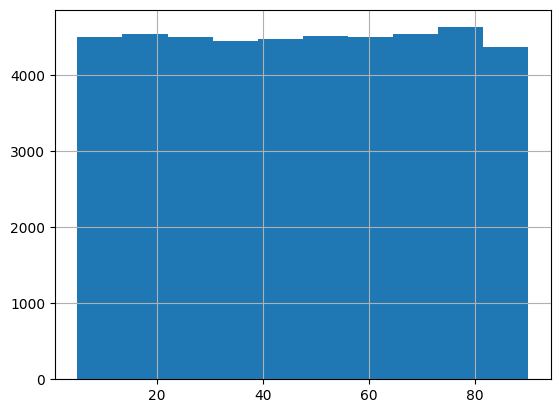

In [ ]:
df["duration_min"].hist()

In [ ]:
df["duration_min"].fillna(df["duration_min"].median(),inplace=True)

/tmp/ipykernel_11728/2912680634.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["duration_min"].fillna(df["duration_min"].median(),inplace=True)


In [ ]:
df.isnull().sum()

,0
trip_id,0
distance_km,0
duration_min,0
base_fare,0
per_km_rate,0
per_min_rate,0
surge_multiplier,0
passenger_count,0
vehicle_type,0
payment_method,0


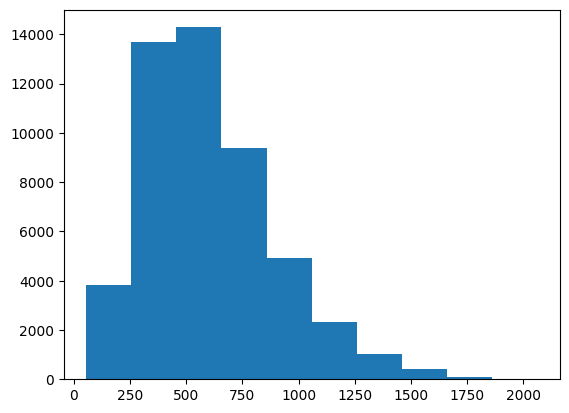

In [ ]:
plt.hist(df['taxi_price'])
plt.show()

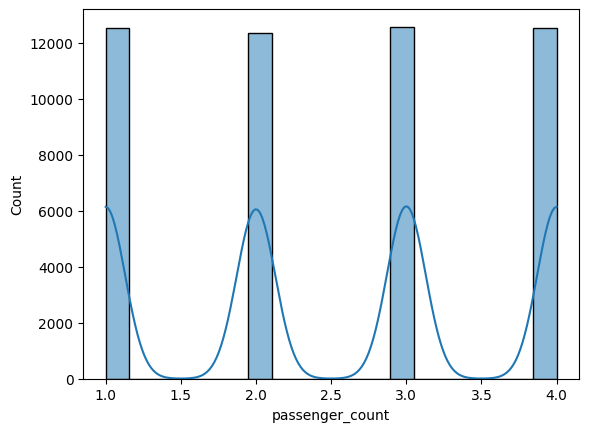

In [ ]:
sns.histplot(df['passenger_count'],kde=True)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trip_id           50000 non-null  int64  
 1   distance_km       50000 non-null  float64
 2   duration_min      50000 non-null  float64
 3   base_fare         50000 non-null  float64
 4   per_km_rate       50000 non-null  float64
 5   per_min_rate      50000 non-null  float64
 6   surge_multiplier  50000 non-null  float64
 7   passenger_count   50000 non-null  int64  
 8   vehicle_type      50000 non-null  object 
 9   payment_method    50000 non-null  object 
 10  time_of_day       50000 non-null  object 
 11  taxi_price        50000 non-null  float64
dtypes: float64(7), int64(2), object(3)
memory usage: 4.6+ MB


In [ ]:
print(df['vehicle_type'].unique())

['SUV' 'Sedan' 'Mini']


In [ ]:
print(df['payment_method'].unique())

['Cash' 'UPI' 'Card']


In [ ]:
print(df['time_of_day'].unique())

['Afternoon' 'Morning' 'Evening' 'Night']


In [ ]:
df['vehicle_type'].replace(['SUV','Sedan','Mini'],[0,1,2],inplace=True)
df['payment_method'].replace(['Cash','UPI','Card'],[0,1,2],inplace=True)
df['time_of_day'].replace(['Afternoon','Morning','Evening','Night'],[0,1,2,3],inplace=True)

/tmp/ipykernel_11728/2530671831.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['vehicle_type'].replace(['SUV','Sedan','Mini'],[0,1,2],inplace=True)
/tmp/ipykernel_11728/2530671831.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['vehicle_type'].replace(['SUV','Sedan','Mini'],[0,1,2],in

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trip_id           50000 non-null  int64  
 1   distance_km       50000 non-null  float64
 2   duration_min      50000 non-null  float64
 3   base_fare         50000 non-null  float64
 4   per_km_rate       50000 non-null  float64
 5   per_min_rate      50000 non-null  float64
 6   surge_multiplier  50000 non-null  float64
 7   passenger_count   50000 non-null  int64  
 8   vehicle_type      50000 non-null  int64  
 9   payment_method    50000 non-null  int64  
 10  time_of_day       50000 non-null  int64  
 11  taxi_price        50000 non-null  float64
dtypes: float64(7), int64(5)
memory usage: 4.6 MB


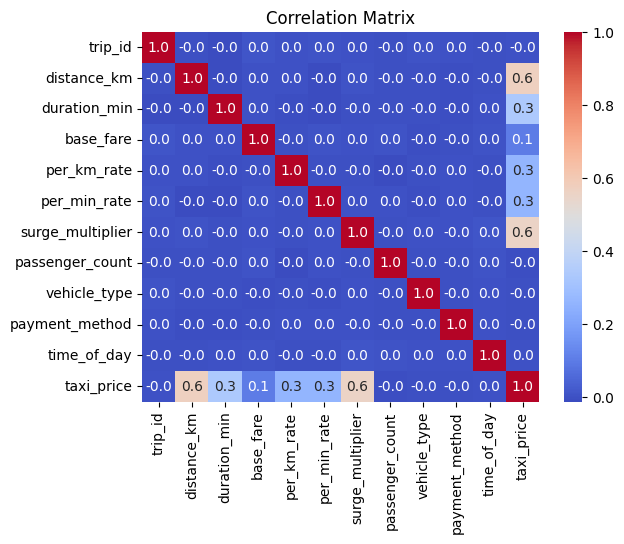

In [ ]:
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

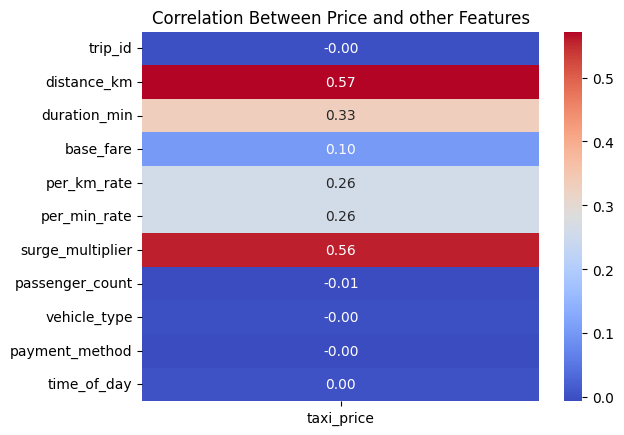

In [ ]:
price_corr=df.corr()['taxi_price']
price_corr=price_corr.drop('taxi_price')

sns.heatmap(price_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title("Correlation Between Price and other Features")
plt.show()

In [ ]:
df.drop(['trip_id','payment_method','time_of_day','vehicle_type'],inplace=True,axis=1)

<Axes: >

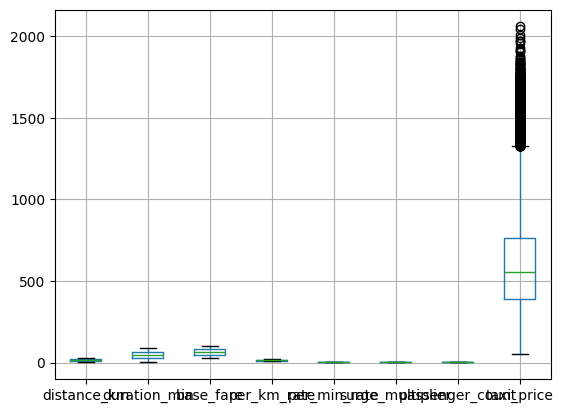

In [ ]:
df.boxplot()

In [ ]:
df.shape

(50000, 8)

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col== exclude_column:
      continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    df=df[(df[col] >=lower_bound) & (df[col] <= upper_bound)]
  return df

# Specify the column to exclude
df_cleaned=remove_outliers_iqr(df,exclude_column='taxi_price')
df=df_cleaned

In [ ]:
df.shape

(50000, 8)

In [ ]:
df.columns

Index(['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count', 'taxi_price'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


features=['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']


scaler=MinMaxScaler()


scaled_data=scaler.fit_transform(df[features])


scaled_df=pd.DataFrame(scaled_data,columns=features)


# **1. LINEAR REGESSION**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:0.90


# **2. DECISION TREE**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=DecisionTreeRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:0.94


# **3.SVR**

In [ ]:
from sklearn.svm import SVR

x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=SVR(kernel='poly',degree=8)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:0.59


# **4. RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=RandomForestRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:.2f}')


Baseline model accuracy:0.98


# **5. ADA BOOST**

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=AdaBoostRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.79


# **6. XGBOOST**

In [ ]:
from  xgboost import XGBRegressor
x=df[['distance_km', 'duration_min', 'base_fare', 'per_km_rate',
       'per_min_rate', 'surge_multiplier', 'passenger_count']]
y=df['taxi_price']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=XGBRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.98
